<a href="https://colab.research.google.com/github/JotaBlanco/TheValley/blob/main/EDA/04-probabilidad/05_A___PROBLEMAS_Probabilidad_Resuelto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# PROBLEMA 1: Ruleta RUSA
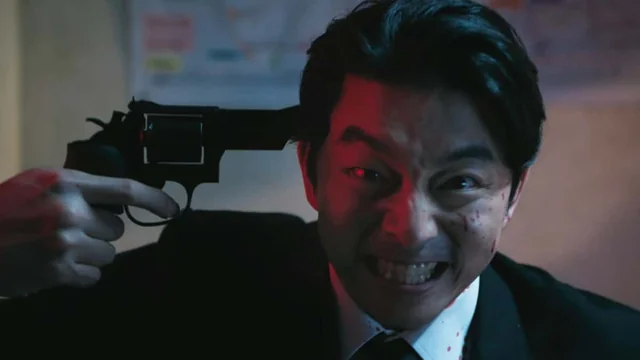

Mira este vídeo un par de veces:
https://www.youtube.com/shorts/fSE360qk1n4


*   1 bala, 6 huecos en la recámara
*   Ronda 1 | Jugador dispara: no hay bala
*   Ronda 2 | Reclutador dispara: no hay bala
*   Ronda 3 | Jugador dispara: no hay bala
*   Ronda 4 | Reclutador dispara: no hay bala
*   Ronda 5 | Jugador dispara: no hay bala
*   Ronda 6 | Reclutador dispara: MUERE (hay bala)


## Tarea: Realiza un análisis probabilístico de un escenario de ruleta rusa.

Establece las variables iniciales (número total de agujeros, número de balas y número de huecos vacíos) y calcula las probabilidades de:
- que la bala salte en cada ronda
- fallecer en cada ronda para los participantes una vez han llegado a esta (probabilidad condicional)
- que cada uno fallezca en cualquier momento del juego (probabilidad acumulada)
- que la bala sea el último disparo

### 01 - Probabilidad Teórica


In [ ]:
# Probabilidad bala salte en cada ronda
1/6

0.16666666666666666

In [ ]:
# Probabilidad Condicionada de Morir en Cada Disparo

num_agujeros = 6
num_balas = 1

for i in range(1, num_agujeros+1): # turnos
    jugador = "Protagonista" if i % 2 != 0 else "Reclutador"

    if num_agujeros > 0:
        prob_morir_condicional = num_balas / num_agujeros
        print(f"Turno {i} ({jugador}):")
        print(f"  Probabilidad de morir: {prob_morir_condicional:.4f} ({num_balas} bala(s) / {num_agujeros} agujero(s))")

    num_agujeros -= 1



Turno 1 (Protagonista):
  Probabilidad de morir: 0.1667 (1 bala(s) / 6 agujero(s))
Turno 2 (Reclutador):
  Probabilidad de morir: 0.2000 (1 bala(s) / 5 agujero(s))
Turno 3 (Protagonista):
  Probabilidad de morir: 0.2500 (1 bala(s) / 4 agujero(s))
Turno 4 (Reclutador):
  Probabilidad de morir: 0.3333 (1 bala(s) / 3 agujero(s))
Turno 5 (Protagonista):
  Probabilidad de morir: 0.5000 (1 bala(s) / 2 agujero(s))
Turno 6 (Reclutador):
  Probabilidad de morir: 1.0000 (1 bala(s) / 1 agujero(s))


In [ ]:
# Probabilidad cada uno fallezca en cualquier momento
fallece_1 = {1, 3, 5}
fallece_2 = {2, 4, 6}
rondas = {1, 2, 3, 4, 5, 6}

# Para calcular la proporción, usa len() para obtener el número de elementos en el set
prob_fallece_1 = len(fallece_1) / len(rondas)
prob_fallece_2 = len(fallece_2) / len(rondas)

print(f"Probabilidad de que el jugador 1 (Protagonista) fallezca: {prob_fallece_1:.4f}")
print(f"Probabilidad de que el jugador 2 (Reclutador) fallezca: {prob_fallece_2:.4f}")

Probabilidad de que el jugador 1 (Protagonista) fallezca: 0.5000
Probabilidad de que el jugador 2 (Reclutador) fallezca: 0.5000


In [ ]:
# Probabilidad bala sea el último disparo
print(1/6)
print(5/6*4/5*3/4*2/3*1/2)

0.16666666666666666
0.16666666666666666


### 02 - Probabilidad Simulada

In [ ]:
def juego_ruleta(num_agujeros_inicial, num_balas_inicial):
    resultados_ronda = {} # Diccionario para almacenar los resultados de una simulación
    agujeros_restantes = num_agujeros_inicial
    balas_restantes = num_balas_inicial

    for ronda in range(1, num_agujeros_inicial + 1):
        prob_disparo = balas_restantes / agujeros_restantes

        if np.random.rand() < prob_disparo: # La bala se dispara
            resultados_ronda[f'Ronda {ronda}'] = 1
            return pd.DataFrame([resultados_ronda]) # se acaba el juego
        else: # Agujero vacío
            resultados_ronda[f'Ronda {ronda}'] = 0
            agujeros_restantes -= 1 # Un agujero menos, pero la bala sigue

In [ ]:
juego_ruleta(num_agujeros_inicial=6, num_balas_inicial=1)

,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5
0,0,0,0,0,1


In [ ]:
# SIMULACIÓN
def escenario_simulacion(num_simulaciones, funcion_sim):
    df_sim = pd.DataFrame()
    for _ in range(num_simulaciones):
        df_sim_i = funcion_sim()
        df_sim = pd.concat([df_sim, df_sim_i], ignore_index=True)

    return df_sim

In [ ]:
# 1 bala
df_1 = escenario_simulacion(
    num_simulaciones = 10000,
    funcion_sim = lambda: juego_ruleta(num_agujeros_inicial=6, num_balas_inicial=1)
    )
df_1

,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6
0,1,NaN,NaN,NaN,NaN,NaN
1,0,1.0,NaN,NaN,NaN,NaN
2,0,0.0,0.0,0.0,1.0,NaN
3,0,0.0,1.0,NaN,NaN,NaN
4,0,0.0,0.0,1.0,NaN,NaN
...,...,...,...,...,...,...
9995,1,NaN,NaN,NaN,NaN,NaN
9996,0,0.0,0.0,0.0,0.0,1.0
9997,0,1.0,NaN,NaN,NaN,NaN
9998,0,1.0,NaN,NaN,NaN,NaN


In [ ]:
# 2 balas
df_2 = escenario_simulacion(
    num_simulaciones = 10000,
    funcion_sim = lambda: juego_ruleta(num_agujeros_inicial=6, num_balas_inicial=2)
    )
df_2

,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5
0,0,0.0,0.0,1.0,NaN
1,0,0.0,0.0,0.0,1.0
2,1,NaN,NaN,NaN,NaN
3,0,0.0,0.0,1.0,NaN
4,0,0.0,0.0,1.0,NaN
...,...,...,...,...,...
9995,0,1.0,NaN,NaN,NaN
9996,0,1.0,NaN,NaN,NaN
9997,0,1.0,NaN,NaN,NaN
9998,0,0.0,1.0,NaN,NaN


In [ ]:
# Probabilidad bala salte en cada ronda
df_1.sum()/len(df_1)

,0
Ronda 1,0.1675
Ronda 2,0.1650
Ronda 3,0.1673
Ronda 4,0.1630
Ronda 5,0.1687
Ronda 6,0.1685


In [ ]:
# Probabilidad bala salte en cada ronda
df_2.sum()/len(df_2)

,0
Ronda 1,0.3327
Ronda 2,0.2668
Ronda 3,0.2020
Ronda 4,0.1291
Ronda 5,0.0694


In [ ]:
# Probabilidad Condicionada de Morir en Cada Disparo
for ronda in df_1.columns:
    prob_morir = df_1[ronda].sum()/df_1[ronda].notnull().sum()
    print(f"Probabilidad de morir en {ronda}: {prob_morir:.4f}")

Probabilidad de morir en Ronda 1: 0.1675
Probabilidad de morir en Ronda 2: 0.1982
Probabilidad de morir en Ronda 3: 0.2506
Probabilidad de morir en Ronda 4: 0.3259
Probabilidad de morir en Ronda 5: 0.5003
Probabilidad de morir en Ronda 6: 1.0000


In [ ]:
# Probabilidad Condicionada de Morir en Cada Disparo (2 balas)
for ronda in df_2.columns:
    prob_morir = df_2[ronda].sum()/df_2[ronda].notnull().sum()
    print(f"Probabilidad de morir en {ronda}: {prob_morir:.4f}")

Probabilidad de morir en Ronda 1: 0.3327
Probabilidad de morir en Ronda 2: 0.3998
Probabilidad de morir en Ronda 3: 0.5044
Probabilidad de morir en Ronda 4: 0.6504
Probabilidad de morir en Ronda 5: 1.0000


In [ ]:
# Probabilidad cada uno fallezca en cualquier momento
n = df_1.shape[1]

even_iloc = list(range(0, n, 2))
print("Jugador 1", even_iloc)

odd_iloc  = list(range(1, n, 2))
print("Jugador 2", odd_iloc)

# Para calcular la proporción, usa len() para obtener el número de elementos en el set
prob_fallece_1 = df_1.iloc[:,even_iloc].sum().sum() / len(df_1)
prob_fallece_2 = df_1.iloc[:,odd_iloc].sum().sum() / len(df_1)

print(f"Probabilidad de que el jugador 1 (Protagonista) fallezca: {prob_fallece_1:.4f}")
print(f"Probabilidad de que el jugador 2 (Reclutador) fallezca: {prob_fallece_2:.4f}")


Jugador 1 [0, 2, 4]
Jugador 2 [1, 3, 5]
Probabilidad de que el jugador 1 (Protagonista) fallezca: 0.5035
Probabilidad de que el jugador 2 (Reclutador) fallezca: 0.4965


np.float64(5035.0)

In [ ]:
# Probabilidad cada uno fallezca en cualquier momento (2 balas)
n = df_2.shape[1]

even_iloc = list(range(0, n, 2))
print("Jugador 1", even_iloc)

odd_iloc  = list(range(1, n, 2))
print("Jugador 2", odd_iloc)

# Para calcular la proporción, usa len() para obtener el número de elementos en el set
prob_fallece_1 = df_2.iloc[:,even_iloc].sum().sum() / len(df_2)
prob_fallece_2 = df_2.iloc[:,odd_iloc].sum().sum() / len(df_2)

print(f"Probabilidad de que el jugador 1 (Protagonista) fallezca: {prob_fallece_1:.4f}")
print(f"Probabilidad de que el jugador 2 (Reclutador) fallezca: {prob_fallece_2:.4f}")

Jugador 1 [0, 2, 4]
Jugador 2 [1, 3]
Probabilidad de que el jugador 1 (Protagonista) fallezca: 0.6041
Probabilidad de que el jugador 2 (Reclutador) fallezca: 0.3959


# PROBLEMA 2: Cumpleaños
- Qué probabilidad existe de que alguien en la clase esté de cumpleaños hoy?
- Cuánta gente tendríamos que estar en clase para que hubiera más opciones de tener a un cumpleañero que de no tenerlo?

### Tarea: Probabilidad de que alguien en la clase cumpla años hoy
Calcula la probabilidad de que al menos una persona en una clase de `N` estudiantes tenga su cumpleaños hoy (un día específico del año). Consideraremos un año no bisiesto (365 días). Intentalo tanto analíticamente como con simulacion.


In [ ]:
# Función para simular si alguien cumple años hoy en una clase
def simular_cumpleanos_hoy(num_personas, num_dias_considerados=1, num_dias_ano=365):
    # Asignar un cumpleaños aleatorio a cada persona (1 a 365)
    cumpleanos = np.random.randint(1, num_dias_ano + 1, num_personas)

    # Comprobar si al menos uno cumple años hoy (en el dia_especifico)
    alguien_cumple_hoy = sum(cumpleanos<=num_dias_considerados)

    return pd.DataFrame([{'cumpleanos_hoy': alguien_cumple_hoy}])

In [ ]:
simular_cumpleanos_hoy(num_personas=5000, num_dias_considerados=1, num_dias_ano=365)

,cumpleanos_hoy
0,16


In [ ]:
num_personas_clase = 25
num_simulaciones = 10000

df_sim = escenario_simulacion(
    num_simulaciones=num_simulaciones,
    funcion_sim=lambda: simular_cumpleanos_hoy(num_personas=num_personas_clase)
)

df_sim

,cumpleanos_hoy
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,0
9997,0
9998,0


In [ ]:
(df_sim['cumpleanos_hoy']>0).sum()/len(df_sim)

np.float64(0.0691)

### Tarea: ¿Cuántas personas para P > 0.5?

Calcula cuántas personas necesitaríamos en una clase para que la probabilidad de que al menos una cumpla años hoy sea mayor que 0.5 (es decir, más de un 50% de posibilidades).

In [ ]:
num_simulaciones = 10000
dic_resultados = {}
for i in range(int(365/2), 365):
    res_i = escenario_simulacion(
            num_simulaciones=num_simulaciones,
            funcion_sim=lambda: simular_cumpleanos_hoy(num_personas=i)
            )['cumpleanos_hoy'].mean()
    print(i, res_i)
    dic_resultados[i] = res_i
    if res_i > 0.5:
        break


182 0.3907
183 0.3903
184 0.3902
185 0.3976
186 0.4005
187 0.4075
188 0.4036
189 0.4053
190 0.4016
191 0.392
192 0.4067
193 0.4031
194 0.4055
195 0.4146
196 0.4182
197 0.4227
198 0.4108
199 0.4256
200 0.427
201 0.4194
202 0.4341
203 0.4188
204 0.4306
205 0.4275
206 0.4348
207 0.4357
208 0.4363
209 0.4361
210 0.4367
211 0.4444
212 0.4457
213 0.4365
214 0.4471
215 0.4519
216 0.4445
217 0.4574
218 0.4557
219 0.4562
220 0.4503
221 0.4531
222 0.4546
223 0.4567
224 0.4628
225 0.4546
226 0.4546
227 0.4554
228 0.4673
229 0.4626
230 0.4703
231 0.4794
232 0.4707
233 0.4715
234 0.4759
235 0.4838
236 0.4766
237 0.4813
238 0.4853
239 0.4849
240 0.4839
241 0.48
242 0.4802
243 0.492
244 0.4937
245 0.4964
246 0.4853
247 0.4874
248 0.4941
249 0.4933
250 0.4982
251 0.5032


<BarContainer object of 70 artists>

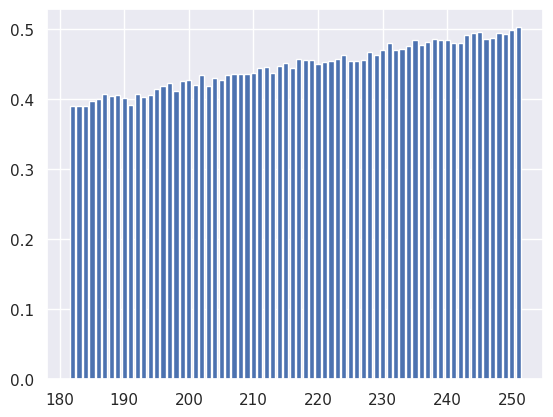

In [ ]:
# 1. Convertimos las llaves del diccionario a una lista para el eje X
plt.bar(list(dic_resultados.keys()), list(dic_resultados.values()))

# PROBLEMA 3: Ruleta infalible
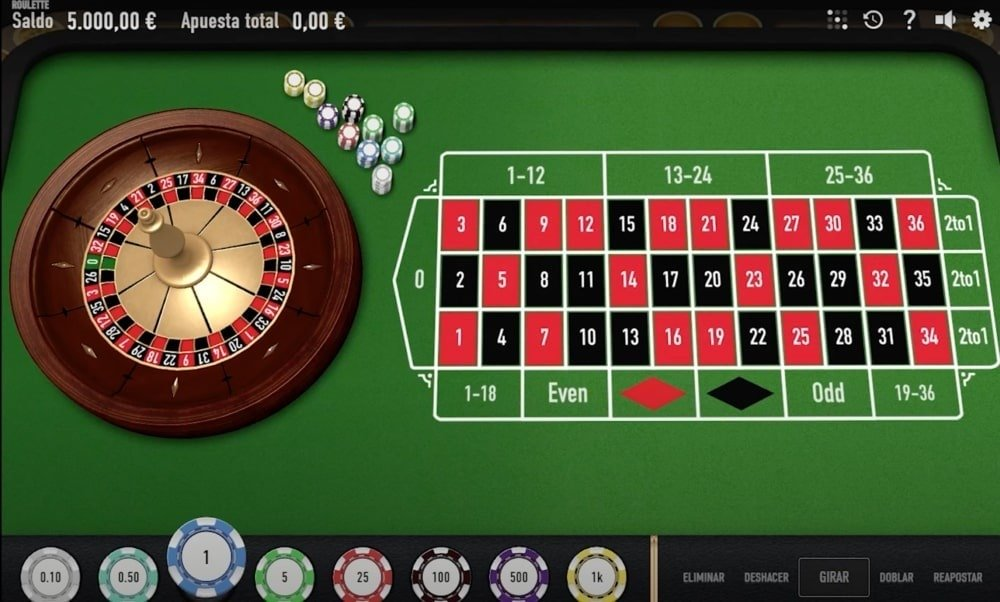



Hay un supuesto método para ganar siempre en la ruleta. Consiste en:


1.   Se apuesta siempre a una apuesta “simple” (rojo/negro, par/impar).

2.   Se empieza apostando una cantidad fija mínima b (por ejemplo, 1€).

3.	Si ganas:
- Obtienes un beneficio neto de +b (1€)
- Vuelves a apostar b

4.	Si pierdes:
- Doblas la apuesta en la siguiente ronda:
2b, 4b, 8b, ... hasta que ganes y recuperes todo lo perdido + 1€ de ganancia.

5.	El juego termina cuando:
- alcanzas un objetivo de beneficio, o
- no puedes cubrir la siguiente apuesta (quiebra)

In [ ]:
def ruleta(capital_inicial, objetivo_beneficio, apuesta_minima=1):
    capital_actual = capital_inicial
    apuesta_actual = apuesta_minima
    rondas_jugadas = 0
    beneficio_obtenido = 0
    capital_por_ronda = {"Ronda 0": capital_inicial}

    playing = True
    while playing:

        apuesta_ganadora = np.random.choice([True, False], p=[18/37, 19/37])
        if apuesta_ganadora:
            capital_actual = capital_actual + apuesta_actual
            apuesta_actual = apuesta_minima
        else:
            capital_actual = capital_actual - apuesta_actual
            apuesta_actual = apuesta_actual * 2

        rondas_jugadas += 1
        capital_por_ronda[f"Ronda {rondas_jugadas}"] = capital_actual
        if capital_actual >= capital_inicial+objetivo_beneficio:
            playing = False
        elif capital_actual <= 0:
            playing = False
        elif capital_actual < apuesta_actual:
            playing = False

    df = pd.DataFrame([capital_por_ronda])
    df.insert(0, "Final", capital_actual)
    df.insert(1, "Rondas", rondas_jugadas)
    return df

In [ ]:
ruleta(capital_inicial=100, objetivo_beneficio=50, apuesta_minima=1)

,Final,Rondas,Ronda 0,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6,Ronda 7,...,Ronda 101,Ronda 102,Ronda 103,Ronda 104,Ronda 105,Ronda 106,Ronda 107,Ronda 108,Ronda 109,Ronda 110
0,150,110,100,101,102,101,103,104,103,101,...,142,146,145,143,147,148,147,149,148,150


### Reto 1 — Salir con +20€ empezando con 100€
Preguntas

	1.	¿Cuál es la probabilidad de conseguir los +20€ sin arruinarse?
	2.	¿Cuántas rondas suele durar el juego cuando se tiene éxito?
	3.	¿Cuál es el beneficio medio del casino?

In [ ]:
capital_inicial = 100
objetivo_beneficio = 20
apuesta_minima = 1
num_simulaciones = 10000

df_sim_1 = escenario_simulacion(
    num_simulaciones=num_simulaciones,
    funcion_sim=lambda: ruleta(capital_inicial, objetivo_beneficio, apuesta_minima)
)

df_sim_1

,Final,Rondas,Ronda 0,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6,Ronda 7,...,Ronda 57,Ronda 58,Ronda 59,Ronda 60,Ronda 61,Ronda 62,Ronda 63,Ronda 64,Ronda 65,Ronda 66
0,49,29,100,99,97,101,102,103,102,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,48,31,100,101,100,98,102,101,99,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,120,31,100,99,97,101,102,103,102,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,120,43,100,99,97,93,85,69,101,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,120,36,100,101,100,98,94,102,103,104.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,120,43,100,99,97,93,101,100,98,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,120,43,100,99,101,100,102,101,103,104.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,56,37,100,101,102,101,103,104,103,101.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,120,39,100,101,102,101,103,102,104,103.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


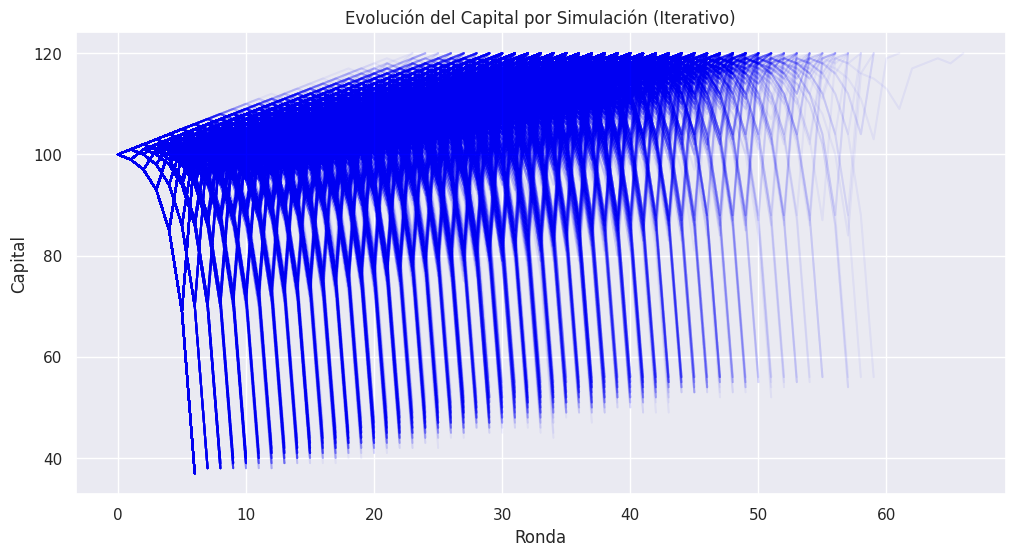

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('Evolución del Capital por Simulación (Iterativo)')
plt.xlabel('Ronda')
plt.ylabel('Capital')

# Método 1: Usando un loop
for i in range(len(df_sim_1)):
    capital_evolution = df_sim_1.iloc[i, 2:].dropna().values
    plt.plot(capital_evolution, color='blue', alpha=0.05) # Alta transparencia para ver la densidad

plt.grid(True)
plt.show()

In [ ]:
# 1 ¿Cuál es la probabilidad de conseguir los +20€?
(df_sim_1["Final"]==120).mean()

np.float64(0.6913)

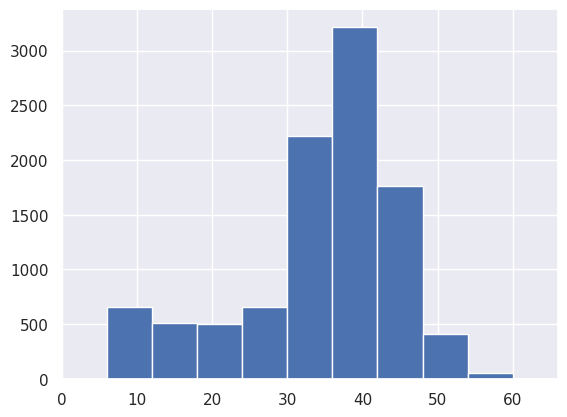

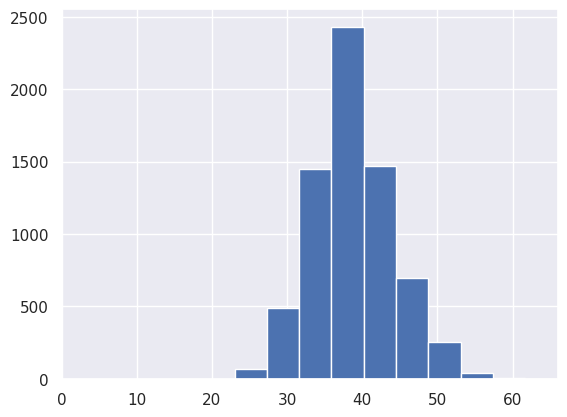

In [ ]:
# 2 ¿Cuántas rondas suele durar el juego cuando se tiene éxito?
plt.hist(df_sim_1["Rondas"])
plt.xlim(0,max(df_sim_1["Rondas"]))
plt.show()
plt.hist(df_sim_1.loc[df_sim_1["Final"]==120,"Rondas"])
plt.xlim(0,max(df_sim_1["Rondas"]))
plt.show()

In [ ]:
display(df_sim_1["Rondas"].describe())
display(df_sim_1.loc[df_sim_1["Final"]==120,"Rondas"].describe())

,Rondas
count,10000.000000
mean,33.868300
std,10.759253
min,6.000000
25%,30.000000
50%,36.000000
75%,41.000000
max,66.000000


,Rondas
count,6913.000000
mean,38.719514
std,5.401972
min,23.000000
25%,35.000000
50%,38.000000
75%,42.000000
max,66.000000


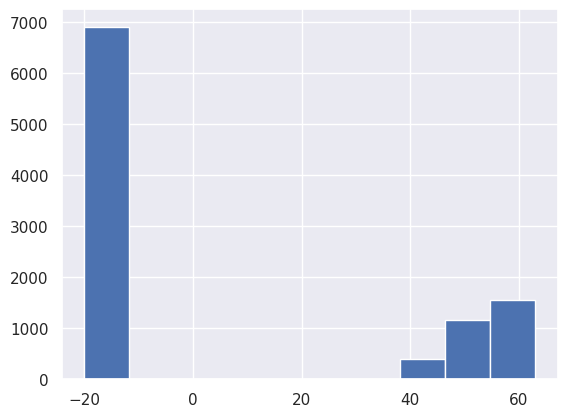

,Final
count,10000.000000
mean,2.908500
std,34.433587
min,-20.000000
25%,-20.000000
50%,-20.000000
75%,48.000000
max,63.000000


In [ ]:
# 3 ¿Cuál es el beneficio medio del casino?
beneficio_casino = 100 - df_sim_1["Final"]
plt.hist(beneficio_casino)
plt.show()
beneficio_casino.describe()

### Reto 2 — Salir cuando doblas el capital (100€ → 200€)

Preguntas

	1.	¿Es mucho menor la probabilidad de éxito que en el reto anterior?
	2.	¿Crece lineal o exponencialmente el riesgo?
	3.	¿Cuál es el beneficio medio del casino?

In [ ]:
capital_inicial = 100
objetivo_beneficio = 100
apuesta_minima = 1
num_simulaciones = 10000

df_sim_2 = escenario_simulacion(
    num_simulaciones=num_simulaciones,
    funcion_sim=lambda: ruleta(capital_inicial, objetivo_beneficio, apuesta_minima)
)

df_sim_2

,Final,Rondas,Ronda 0,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6,Ronda 7,...,Ronda 240,Ronda 241,Ronda 242,Ronda 243,Ronda 244,Ronda 245,Ronda 246,Ronda 247,Ronda 248,Ronda 249
0,49,169,100,99,101,102,101,103,102,104.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200,182,100,99,101,100,98,94,86,70.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13,90,100,99,101,100,98,102,103,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24,122,100,99,97,101,100,102,103,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,60,166,100,99,97,93,85,69,101,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,61,167,100,99,101,100,98,102,101,99.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,60,55,100,99,97,101,102,103,104,105.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,200,189,100,101,100,98,94,86,70,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,53,32,100,101,100,102,103,102,104,103.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


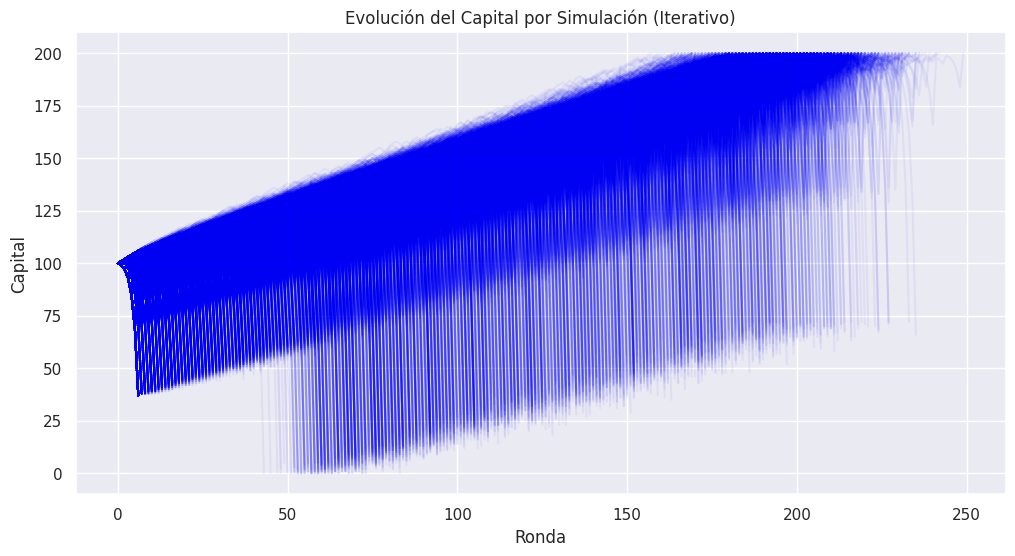

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('Evolución del Capital por Simulación (Iterativo)')
plt.xlabel('Ronda')
plt.ylabel('Capital')

# Método 1: Usando un loop
for i in range(len(df_sim_2)):
    capital_evolution = df_sim_2.iloc[i, 2:].dropna().values
    plt.plot(capital_evolution, color='blue', alpha=0.05) # Alta transparencia para ver la densidad

plt.grid(True)
plt.show()

In [ ]:
# 1 ¿Es mucho menor la probabilidad de éxito que en el reto anterior?
print((df_sim_1["Final"]==120).mean())
print((df_sim_2["Final"]==200).mean())

0.6913
0.2977


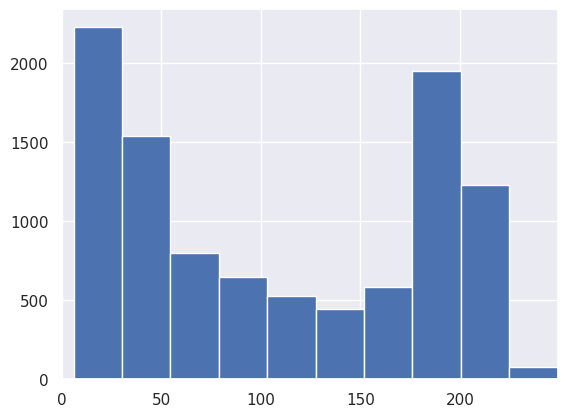

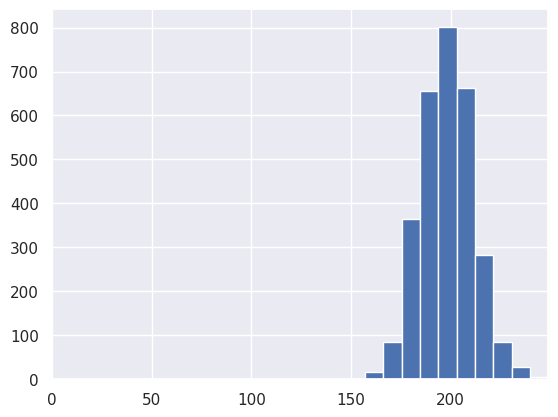

In [ ]:
# 2 ¿Crece lineal o exponencialmente el riesgo?
plt.hist(df_sim_2["Rondas"])
plt.xlim(0,max(df_sim_2["Rondas"]))
plt.show()
plt.hist(df_sim_2.loc[df_sim_2["Final"]==200,"Rondas"])
plt.xlim(0,max(df_sim_2["Rondas"]))
plt.show()

In [ ]:
display(df_sim_2["Rondas"].describe())
display(df_sim_2.loc[df_sim_2["Final"]==200,"Rondas"].describe())

,Rondas
count,10000.000000
mean,107.462700
std,75.147774
min,6.000000
25%,35.000000
50%,95.000000
75%,188.000000
max,249.000000


,Rondas
count,2977.000000
mean,197.812563
std,12.905381
min,157.000000
25%,189.000000
50%,197.000000
75%,206.000000
max,249.000000


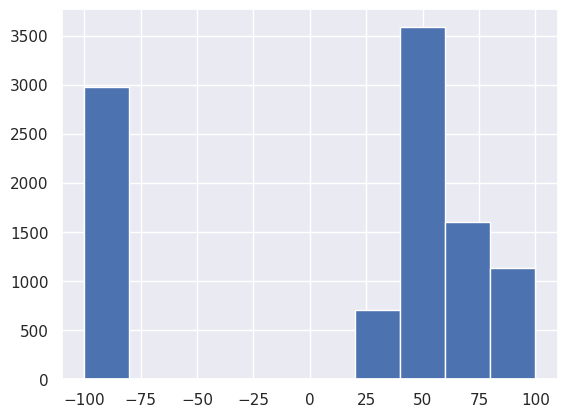

,Final
count,10000.000000
mean,11.548100
std,74.060323
min,-100.000000
25%,-100.000000
50%,48.000000
75%,61.000000
max,100.000000


In [ ]:
# 3 ¿Cuál es el beneficio medio del casino?
beneficio_casino = 100 - df_sim_2["Final"]
plt.hist(beneficio_casino)
plt.show()
beneficio_casino.describe()